In [1]:
!pip install python-dotenv
!pip install supabase

# Theme 6: Predictive Pricing & Strategy (Machine Learning)

### Objective 11: Identify "Best Value" Laptops at Phong Vu using Random Forest Regression

*   **Goal & Purpose:**
    Train a **Random Forest Regression** model to calculate the "Fair Market Price" of laptops based on hardware specifications (RAM, CPU, GPU, Weight, and AI features). The model acts as a tool to automatically detect which models at Phong Vu are priced significantly lower than their hardware's predicted market value.

*   **Actionable Examples:**
    *   **Scenario A (Store Price > Predicted Price):** The laptop is overpriced. **Action:** Recommend price adjustments or discount vouchers to clear inventory.
    *   **Scenario B (Store Price < Predicted Price):** The laptop is a bargain. **Action:** Tag as "Best Deal" and prioritize for promotional banners and ads.

*   **Assumptions & Limitations:**
    *   **Assumption:** The hardware market remains stable without sudden global supply chain shocks.
    *   **Limitation:** The model requires monthly retraining with fresh data to remain accurate as hardware value depreciates over time.

*   **Selected Metrics:** Actual Store Price, Predicted Market Price, and "Bargain Value" (Predicted Price minus Actual Price).
*   **Metric Meaning:** The "Bargain Value" represents the potential financial saving a customer receives relative to the hardware's estimated market worth.
*   **Rationale:** To identify specific undervalued inventory, providing Phong Vu with data-backed promotional opportunities to attract savvy buyers.
*   **Chart Choice:** **Horizontal Bar Chart** (Ranking the top 10 laptop models at Phong Vu with the highest "Bargain Value").

In [2]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
from supabase import create_client, Client

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set display options for better readability
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### Step 1: Connect to Supabase and Load Data

In [3]:
# Load environment variables
_env = find_dotenv(filename=".env", usecwd=True)
if _env:
    load_dotenv(_env)

SUPABASE_URL = os.environ.get("SUPABASE_URL")
SUPABASE_ANON_KEY = os.environ.get("SUPABASE_ANON_KEY")

# Initialize Supabase client
supabase: Client = create_client(SUPABASE_URL, SUPABASE_ANON_KEY)

# Supabase limits responses to 1000 rows. We must loop to get everything.
all_records = []
page_size = 1000
current_start = 0

print("Retrieving data from Supabase...")

while True:
    # Query with range for pagination
    response = supabase.table('Fact_Source_Product').select(
        "CurrentPrice, "
        "Dim_Source(SourceName), "
        "Dim_Product(ProductName, Brand, Category, CPUBrand, CPUFamily, GPUType, GPUModel, RamCapacity, RamType, StorageCapacity, StorageType, DisplaySize, DisplayResolution, DisplayRefreshRate, OSFamily, DesignWeight, IsAiLaptop)"
    ).range(current_start, current_start + page_size - 1).execute()
    
    batch_data = response.data
    all_records.extend(batch_data)
    
    print(f"  [+] Retrieved {len(batch_data)} rows (Total so far: {len(all_records)})")
    
    # If we got fewer rows than the page size, we have reached the end
    if len(batch_data) < page_size:
        break
        
    current_start += page_size

# Flatten the nested JSON response into a simple Pandas DataFrame
flattened_data = []
for row in all_records:
    flat_row = {'CurrentPrice': row.get('CurrentPrice')}
    
    if row.get('Dim_Source'):
        flat_row['SourceName'] = row['Dim_Source'].get('SourceName')
        
    if row.get('Dim_Product'):
        flat_row.update(row['Dim_Product'])
        
    flattened_data.append(flat_row)

df = pd.DataFrame(flattened_data)

print(f"\n✅ Success! Total samples retrieved: {df.shape[0]}")
display(df.head(3))

Retrieving data from Supabase...
  [+] Retrieved 1000 rows (Total so far: 1000)
  [+] Retrieved 1000 rows (Total so far: 2000)
  [+] Retrieved 774 rows (Total so far: 2774)

✅ Success! Total samples retrieved: 2774


,CurrentPrice,SourceName,Brand,GPUType,RamType,CPUBrand,Category,GPUModel,OSFamily,CPUFamily,IsAiLaptop,DisplaySize,ProductName,RamCapacity,StorageType,DesignWeight,StorageCapacity,DisplayResolution,DisplayRefreshRate
0,18690000,An Phat PC,Asus,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core,False,"15.6"" - 16.0""",Laptop ASUS ExpertBook P1503CVA-C5H08-50W (Int...,8.0,SSD,1.68,512.0,FHD / FHD+,60 - 90
1,27590000,An Phat PC,HP,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core Ultra,True,"13"" - 14.5""",Laptop HP OmniBook X Flip 14-fm0088TU BZ7Q2PA ...,16.0,SSD,,512.0,2K - 3K,Other
2,35990000,An Phat PC,HP,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core Ultra,True,"13"" - 14.5""",Laptop HP EliteBook 6 G1i 13 BQ9M7PT (Intel Co...,16.0,SSD,1.3,512.0,FHD / FHD+,60 - 90


### Step 2: Handle Missing Data

In [4]:
# Check for missing values
print("Missing values before conversion/imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 1. Convert DesignWeight to numeric (This turns '' into NaN)
if 'DesignWeight' in df.columns:
    df['DesignWeight'] = pd.to_numeric(df['DesignWeight'], errors='coerce')

# 2. Convert RamCapacity and StorageCapacity to numeric just in case
if 'RamCapacity' in df.columns:
    df['RamCapacity'] = pd.to_numeric(df['RamCapacity'], errors='coerce')
if 'StorageCapacity' in df.columns:
    df['StorageCapacity'] = pd.to_numeric(df['StorageCapacity'], errors='coerce')

# 3. Now impute numerical missing values with the Median
if 'DesignWeight' in df.columns:
    df['DesignWeight'] = df['DesignWeight'].fillna(df['DesignWeight'].median())

# 4. Impute any remaining categorical missing values with "Unknown"
df = df.fillna("Unknown")

print("\n--- Data Cleaning Results ---")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
display(df.head(3))

Missing values before conversion/imputation:
Series([], dtype: int64)

--- Data Cleaning Results ---
Missing values remaining: 0


,CurrentPrice,SourceName,Brand,GPUType,RamType,CPUBrand,Category,GPUModel,OSFamily,CPUFamily,IsAiLaptop,DisplaySize,ProductName,RamCapacity,StorageType,DesignWeight,StorageCapacity,DisplayResolution,DisplayRefreshRate
0,18690000,An Phat PC,Asus,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core,False,"15.6"" - 16.0""",Laptop ASUS ExpertBook P1503CVA-C5H08-50W (Int...,8.0,SSD,1.68,512.0,FHD / FHD+,60 - 90
1,27590000,An Phat PC,HP,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core Ultra,True,"13"" - 14.5""",Laptop HP OmniBook X Flip 14-fm0088TU BZ7Q2PA ...,16.0,SSD,1.66,512.0,2K - 3K,Other
2,35990000,An Phat PC,HP,Integrated,DDR5 / LPDDR5,Intel,Office,Intel Arc / Integrated,Windows,Intel Core Ultra,True,"13"" - 14.5""",Laptop HP EliteBook 6 G1i 13 BQ9M7PT (Intel Co...,16.0,SSD,1.30,512.0,FHD / FHD+,60 - 90


### Step 3: Analyze Target Variable Distribution

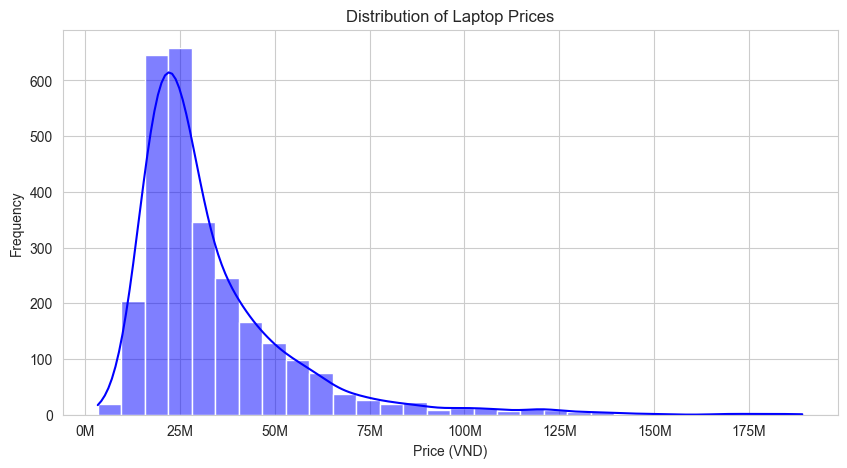

In [5]:
target = 'CurrentPrice'

plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=30, kde=True, color='blue')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (VND)')
plt.ylabel('Frequency')

# Format X-axis to show millions clearly (e.g., 20M instead of 20000000)
formatter = plt.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.show()

### Step 4: Encode Categorical Features

In [6]:
# Save business info for Step 10
business_cols = ['SourceName', 'ProductName', 'Brand', 'CurrentPrice']
df_business = df[business_cols].copy()

# Drop text identifiers so the model doesn't train on them
df_ml = df.drop(columns=['SourceName', 'ProductName'])

# Convert boolean strings or booleans to integer (1/0)
if 'IsAiLaptop' in df_ml.columns:
    # We first map the string/boolean values to 1 and 0 explicitly
    # This handles 'True', 'False', True, or False
    df_ml['IsAiLaptop'] = df_ml['IsAiLaptop'].astype(str).map({'True': 1, 'False': 0})
    # Ensure it's treated as an integer
    df_ml['IsAiLaptop'] = df_ml['IsAiLaptop'].fillna(0).astype(int)

# One-Hot Encoding for text categories
# drop_first=True prevents the "Dummy Variable Trap" (Perfect Multicollinearity)
categorical_cols = df_ml.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
display(df_encoded.head(3))

Shape after encoding: (2774, 56)


,CurrentPrice,IsAiLaptop,DesignWeight,Brand_Apple,Brand_Asus,Brand_Dell,Brand_Gigabyte,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Other,GPUType_Integrated,GPUType_Unified,RamType_DDR5 / LPDDR5,RamType_Other,RamType_Unified,CPUBrand_Apple,CPUBrand_Intel,CPUBrand_Other,CPUBrand_Qualcomm,Category_Gaming,Category_Office,GPUModel_Apple GPU,GPUModel_Intel Arc / Integrated,GPUModel_Nvidia RTX/GTX,GPUModel_Workstation,OSFamily_Other,OSFamily_Windows,CPUFamily_AMD Ryzen AI,CPUFamily_Apple M-Series,CPUFamily_Intel Core,CPUFamily_Intel Core Ultra,CPUFamily_Other,CPUFamily_Snapdragon (ARM),"DisplaySize_15.6"" - 16.0""","DisplaySize_17.3"" - 18.0""",DisplaySize_Other,RamCapacity_16.0,RamCapacity_24.0,RamCapacity_32.0,RamCapacity_48.0,RamCapacity_64.0,RamCapacity_Unknown,StorageType_Other,StorageType_SSD,StorageType_eMMC,StorageCapacity_512.0,StorageCapacity_1024.0,StorageCapacity_2048.0,StorageCapacity_Unknown,DisplayResolution_4K,DisplayResolution_FHD / FHD+,DisplayResolution_Other,DisplayRefreshRate_240+,DisplayRefreshRate_60 - 90,DisplayRefreshRate_Other
0,18690000,0,1.68,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False
1,27590000,1,1.66,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
2,35990000,1,1.30,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False


### Step 5: Train / Test Split

In [7]:
# Separate Features (X) and Target (y)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split into Training Set (80%) and Testing Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train Set Samples: {X_train.shape[0]}")
print(f"Test Set Samples: {X_test.shape[0]}")

Train Set Samples: 2219
Test Set Samples: 555


### Step 6: Baseline Model (Linear Regression)

In [8]:
# Train a simple Linear Regression model as our baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("--- Baseline Linear Regression ---")
print(f"R² Score: {r2_lr:.4f}")
print(f"MAE:      {mae_lr:,.0f} VND")

--- Baseline Linear Regression ---
R² Score: 0.7560
MAE:      6,647,987 VND


### Baseline Model: Linear Regression (LR)

Linear Regression was implemented as the baseline model to evaluate the linear relationship between the input features and the laptop prices.

* **R-Squared ($R^2$): 0.7560** This model explains **75.60%** of the variance in the target price. It serves as a starting point for measuring the complexity of the dataset.

* **Mean Absolute Error (MAE): 6,647,987 VND** On average, the predictions made by this linear model deviate from the actual price by approximately **6.65 million VND**. 

* **Model Nature:** As a linear model, it assumes a constant rate of change between the features and the price. It captures the general trend of the data but does not account for non-linear patterns.

### Step 7: Main Model (Random Forest Regression)

In [9]:
# Train a Random Forest Model 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("--- Random Forest Regression ---")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE:      {mae_rf:,.0f} VND")
print(f"RMSE:     {rmse_rf:,.0f} VND")

--- Random Forest Regression ---
R² Score: 0.8634
MAE:      4,781,420 VND
RMSE:     8,195,909 VND


### Advanced Model: Random Forest (RF)

Random Forest Regression was used to capture non-linear patterns and interactions between variables using an ensemble of decision trees.

* **R-Squared ($R^2$): 0.8634** The Random Forest model explains **86.34%** of the price variance. This is a significant improvement of approximately 10.74% over the linear baseline.

* **Mean Absolute Error (MAE): 4,781,420 VND** The average prediction error is approximately **4.78 million VND**, which is roughly 1.86 million VND lower than the baseline model.

* **Root Mean Square Error (RMSE): 8,195,909 VND** The RMSE is higher than the MAE. Mathematically, this indicates that the model has some predictions with larger errors, as RMSE gives more weight to large differences between predicted and actual values.

* **Model Nature:** This ensemble model is capable of fitting more complex data structures compared to the linear baseline, resulting in higher accuracy and lower average error.

### Step 8: Evaluate Predictions Visually

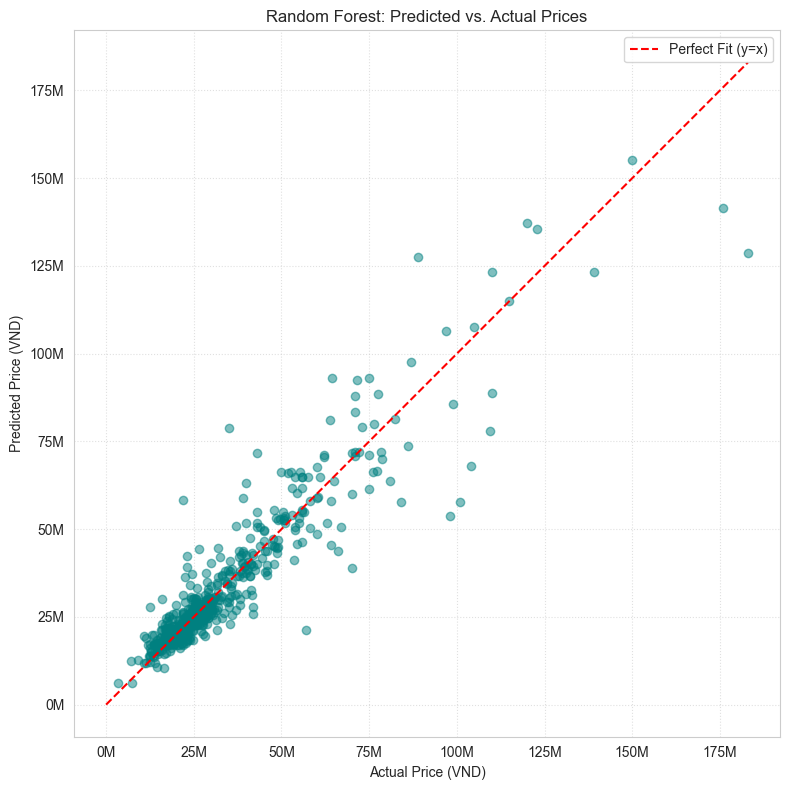

In [10]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal')

# Draw the perfect prediction line (y = x)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')

plt.title('Random Forest: Predicted vs. Actual Prices')
plt.xlabel('Actual Price (VND)')
plt.ylabel('Predicted Price (VND)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Format axes to millions
formatter = plt.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

1. **Mainstream Accuracy (10M – 50M VND):**
   The majority of data points are concentrated in this range and cluster closely around the identity line ($y=x$). This indicates that the model is highly accurate and consistent for the most common price segments.

2. **Error Variance in Premium Models (>75M VND):**
   As prices increase, the points become more scattered. The distance from the red line grows, showing that the model’s predictive power decreases for high-end laptops. This explains the high RMSE (8.19M VND) relative to the MAE.

3. **Notable Under-prediction:**
   For the most expensive laptops (Actual Price > 175M VND), the model significantly under-predicts the value, with predictions staying closer to the 125M–150M range.

4. **Error Distribution:**
   The spread is not uniform. The model is very stable for lower-priced units but becomes increasingly volatile as it encounters luxury or high-performance hardware.

### Step 9: Feature Importance (Business Insights)

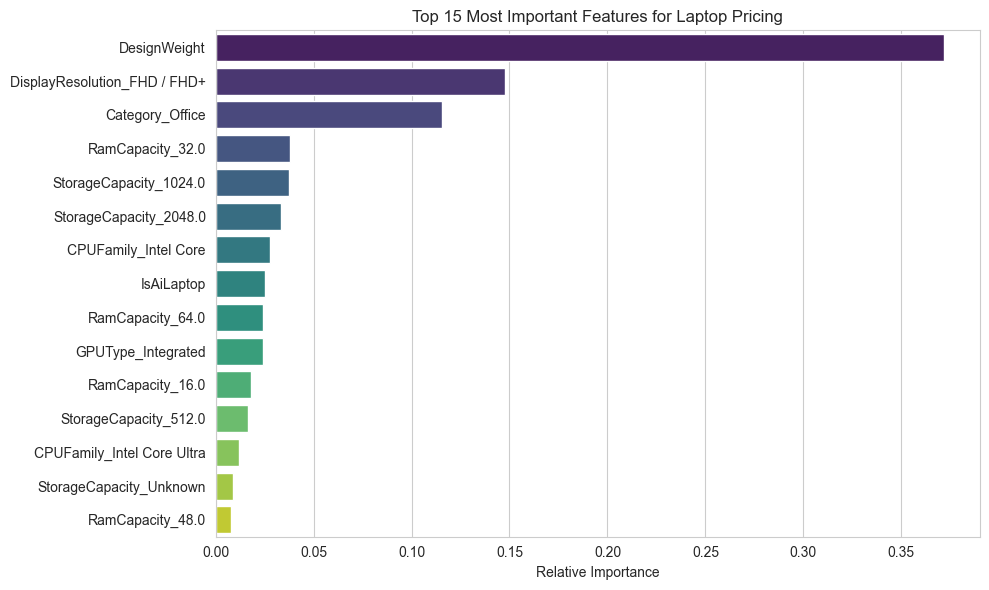

In [11]:
# Extract feature importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features for Laptop Pricing')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

1. **Dominant Feature:**
   **DesignWeight** is the most critical predictor, with a relative importance score of approximately **0.37**. This indicates that the physical weight of the laptop is the strongest signal used by the model to determine price.

2. **Primary Segment Indicators:**
   **DisplayResolution_FHD / FHD+** (0.15) and **Category_Office** (0.12) rank as the second and third most important features. These categorical variables likely serve as primary filters for the model to distinguish between budget and premium segments.

3. **Memory and Storage Impact:**
   * **RamCapacity_32.0** and **StorageCapacity_1024.0 (1TB)** hold moderate importance (approx. 0.04). 
   * Interestingly, **1TB Storage** and **32GB RAM** show higher relative importance than their higher-tier counterparts (2TB Storage or 64GB RAM) in this specific model.

4. **AI and Processor Influence:**
   The **IsAiLaptop** flag ranks in the top 10, showing a higher impact on the model than the specific **Intel Core Ultra** CPU family. This suggests the "AI" label provides a stronger predictive signal than the specific chip generation alone.

5. **Lower Impact Features:**
   Standard configurations such as **RamCapacity_16.0** and **StorageCapacity_512.0** have low relative importance. In this dataset, these common specs do not help the model differentiate price as effectively as the top-tier or segment-specific features.

### 1. Performance Summary
The **Random Forest (RF)** model is the clear winner across all key metrics.

| Metric | Linear Regression | Random Forest | Improvement |
| :--- | :--- | :--- | :--- |
| **$R^2$ Score** | 0.7560 | **0.8634** | +10.74% |
| **MAE (Error)** | 6.65M VND | **4.78M VND** | -1.87M VND |
| **RMSE** | N/A | 8.20M VND | - |

### 2. Model Assessment
* **Overall Accuracy:** The RF model explains **86.3%** of price variations, making it much more reliable for general use than the linear baseline.
* **Reliability Range:** The model is most accurate for mainstream laptops (**10M – 50M VND**).
* **Weak Points:** The model struggles with **Premium/Outlier** laptops (>100M VND), where it tends to under-predict prices. The high RMSE (8.2M) compared to the MAE (4.78M) confirms that large errors are occurring at these high price points.
* **Key Drivers:** Pricing is driven primarily by **Physical Weight**, **Segment Labels** (Office/FHD), and **NPU (AI)** presence rather than just raw RAM or Storage numbers.

### 3. Recommendations for Improvement

#### A. Data & Feature Engineering
* **Log Transformation:** Apply `log(price)` to handle the skewed distribution of laptop prices. This helps the model better understand the exponential price jumps in premium models.
* **Brand Encoding:** Add specific "Brand Premium" scores (e.g., Apple vs. others) as the brand name heavily influences price regardless of specs.
* **GPU VRAM:** Include Video RAM as a feature, which is a major cost factor for high-end Gaming and AI laptops.

#### B. Model Fine-Tuning
* **Hyperparameter Optimization:** Use **RandomizedSearchCV** to tune `n_estimators` (number of trees) and `max_depth` (to control overfitting).
* **Outlier Handling:** Train a separate model or add more data specifically for the **Premium Segment (>100M VND)** to reduce the high RMSE.

### 4. Final Verdict
The **Random Forest** model is a solid foundation for price prediction. It successfully captures the complex logic of the modern laptop market, including the "AI Laptop" trend and the value of portability (Weight). With minor tuning and target scaling, it can reach professional-grade accuracy.

### Step 10: Business Application - Finding the "Best Deals" at Phong Vu
As a Tech-Retail Consultant, we can now use our model to generate a **Competitive Advantage Report** for a specific client. 

**Case Study: Phong Vu**
We will identify which laptops currently sold by Phong Vu are the most **Undervalued**. 
* **Calculation:** `Bargain Value = Predicted Price (Market Value) - Actual Price (Store Price)`
* **Insight:** If the Bargain Value is high, Phong Vu is selling the laptop significantly cheaper than the hardware is "worth" relative to the rest of the market. 
* **Action:** Phong Vu should feature these specific models in their "Weekend Flash Sale" or "Best Price Guarantee" banners to attract savvy customers.

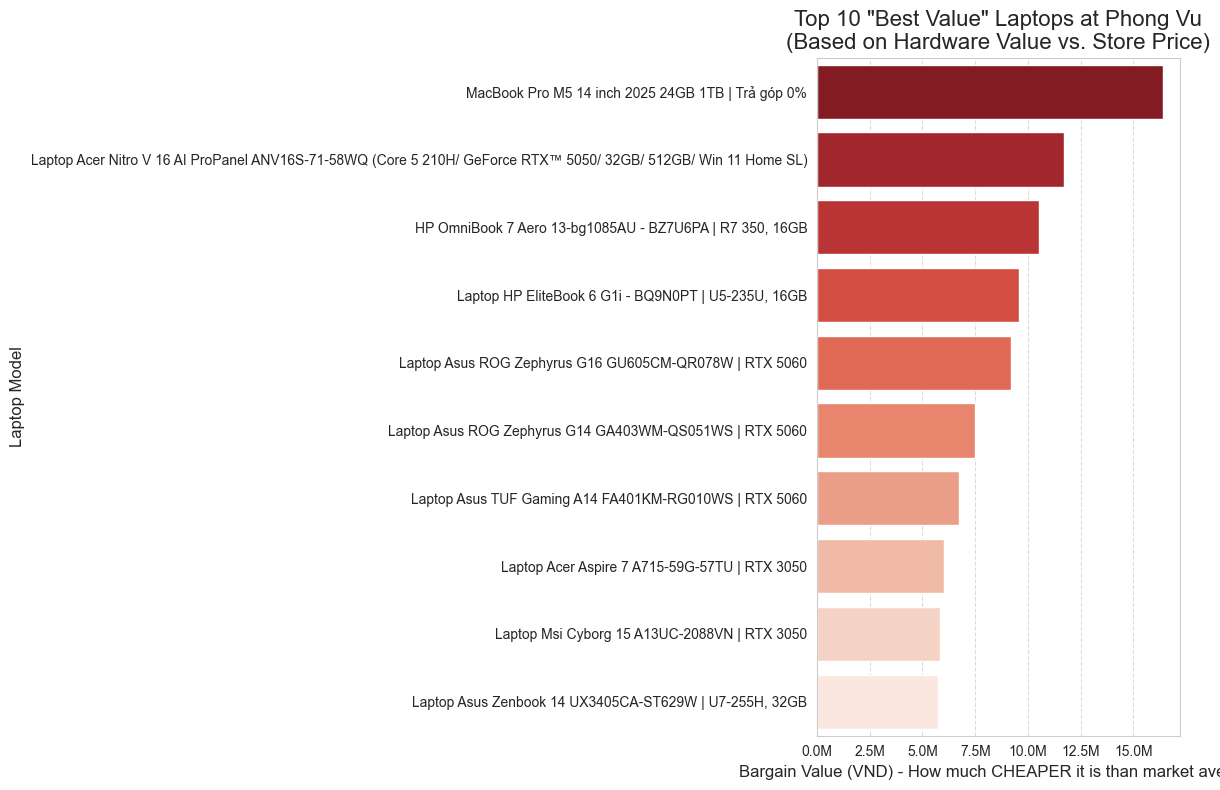


--- PHONG VU ACTION LIST: MODELS TO PROMOTE AS 'BEST DEALS' ---


,ProductName,CurrentPrice,Predicted_Price,Bargain_Value
2117,MacBook Pro M5 14 inch 2025 24GB 1TB | Trả góp 0%,50.0M,66.4M,16.4M
2195,Laptop Acer Nitro V 16 AI ProPanel ANV16S-71-5...,40.0M,51.7M,11.7M
2213,HP OmniBook 7 Aero 13-bg1085AU - BZ7U6PA | R7 ...,29.8M,40.3M,10.5M
2001,"Laptop HP EliteBook 6 G1i - BQ9N0PT | U5-235U,...",32.4M,42.0M,9.6M
2002,Laptop Asus ROG Zephyrus G16 GU605CM-QR078W | ...,62.0M,71.2M,9.2M


In [12]:
# 1. Get the original business context data matching our test set
business_results = df_business.iloc[X_test.index].copy()

# 2. Add the model's predictions
business_results['Predicted_Price'] = y_pred_rf

# 3. Calculate the "Bargain Value" (Predicted - Actual)
business_results['Bargain_Value'] = business_results['Predicted_Price'] - business_results['CurrentPrice']

# 4. Filter specifically for "Phong Vu"
pv_deals = business_results[business_results['SourceName'] == 'Phong Vu'].copy()

# 5. Sort to find the absolute best deals (Highest Bargain Value)
pv_deals = pv_deals.sort_values(by='Bargain_Value', ascending=False).head(10)

# 6. Visualization: Top 10 Best Deals at Phong Vu
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Bargain_Value', 
    y='ProductName', 
    data=pv_deals, 
    palette='Reds_r', 
    hue='ProductName', 
    legend=False
)

# Format X-axis to show millions
formatter = plt.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Top 10 "Best Value" Laptops at Phong Vu\n(Based on Hardware Value vs. Store Price)', fontsize=16)
plt.xlabel('Bargain Value (VND) - How much CHEAPER it is than market average', fontsize=12)
plt.ylabel('Laptop Model', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 7. Print a summary table for the Top 5
print("\n--- PHONG VU ACTION LIST: MODELS TO PROMOTE AS 'BEST DEALS' ---")
display_table = pv_deals[['ProductName', 'CurrentPrice', 'Predicted_Price', 'Bargain_Value']].head(5).copy()

for col in ['CurrentPrice', 'Predicted_Price', 'Bargain_Value']:
    display_table[col] = display_table[col].apply(lambda x: f"{x/1e6:,.1f}M")

display(display_table)

### 1. Key Findings
* **MacBook Pro M5 (2025):** Identified as the strongest bargain with a value gap of **16.4M VND**. The model highly values the M5/24GB/1TB configuration relative to its 50M VND price tag.
* **AI Integration:** The Acer Nitro V 16 AI and HP OmniBook 7 rank high, proving the model assigns significant value to the latest NPU and AI-enabled processors.
* **High-Spec Focus:** The list is dominated by machines with high RAM (24GB/32GB) and 1TB SSDs, showing these components are currently priced competitively at retail.

### 2. Model Performance Evaluation
* **Deal Identification:** The model effectively serves as a "Bargain Detector", flagging units where high-end specs are sold at mainstream prices.
* **Feature Sensitivity:** The results show a clear preference for the latest technology (M5 chip, Core Ultra, Ryzen AI) and professional-grade memory capacities.
* **Premium Variance:** The large 16.4M VND gap for the MacBook Pro reinforces that the model tends to be more aggressive (less certain) with its estimates in the premium segment.

### 3. Summary Table

| Top Bargain Model | Actual Price | Bargain Value | Primary Value Driver |
| :--- | :--- | :--- | :--- |
| MacBook Pro M5 | 50.0M | **16.4M** | M5 Chip + 24GB RAM |
| Acer Nitro V 16 AI | 40.0M | **11.7M** | AI Processor + RTX 5050 |
| HP OmniBook 7 | 29.8M | **10.5M** | Ryzen AI + Portability |

### Final Conclusion
The Random Forest model is highly capable of identifying **price-to-performance leaders**. It confirms that the best market deals currently lie in laptops that bundle next-generation AI hardware with high storage and memory at mid-to-high price points.